# Notebook 2 — Model Fitting

**Bachelor thesis:** Testing Market Efficiency: Evidence from the US Dollar Index and Emerging Markets *(US Dollar Index — DXY)*

---

**Previous notebook:** Notebook 01 produced the processed feature dataset (`dxy_dataset_features/target.csv`) — run it first.

**This notebook:**
1. Fit **ARIMA(0,0,0)** (EMH baseline), **two-step** ARIMA/ARIMAX+GARCH, and **joint** AR/ARX+GARCH (`arch` MLE, **AIC**-selected AR lags — independent search for univariate vs exog case)
2. Fit **Ridge** and **Lasso** regression on 15 features (same as ML models in notebook 03)
3. Generate rolling one-step-ahead out-of-sample forecasts for all **seven** core models (baseline, two-step ARIMA/ARIMAX+GARCH, **joint** AR/ARX+GARCH, Ridge, Lasso)
4. Compare models with RMSE, MAE, R², directional accuracy
5. Statistical significance tests — Diebold-Mariano, Variance Ratio, Runs test, ARCH-LM on residuals
6. **Likelihood Ratio Tests** — in-sample validation of GARCH on ARIMA residuals and AR/MA structure (two-step); supplementary tests in the joint `arch` block (incl. exog there)

**Output:** fitted model files (`*.pkl`) and `lasso_predictions.csv` saved to disk.


Library imports and project module setup.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import sys
from pathlib import Path

# Project root = directory that contains src/models/arimagarch_model.py (not ".."
# blindly — Cursor/Jupyter cwd is not always notebooks/).
for _p in [Path.cwd().resolve(), Path.cwd().resolve().parent]:
    if (_p / "src" / "models" / "arimagarch_model.py").is_file():
        if str(_p) not in sys.path:
            sys.path.insert(0, str(_p))
        break

from config import config
from src.data.processor import DataProcessor
from src.models.arima_model import ARIMAModel
from src.models.regression_models import RidgeLassoModel
from src.models.twostep_model import TwoStepARIMAGARCHModel

import importlib
import src.models.arimagarch_model as _am_module
importlib.reload(_am_module)
from src.models.arimagarch_model import ARIMAGARCHModel

from src.validation.metrics import MetricsCalculator
from src.validation.model_comparison import ModelComparator

print(f"✓ ARIMAGARCHModel loaded from: {_am_module.__file__}")
print(f"✓ Has _arch_forecast_x_from_result: {hasattr(ARIMAGARCHModel, '_arch_forecast_x_from_result')}")
print("✓ All imports successful!")


✓ ARIMAGARCHModel loaded from: C:\Users\rosts\Desktop\Python\Projects\Diplom - copy\DXY_part\src\models\arimagarch_model.py
✓ Has _arch_forecast_x_from_result: True
✓ All imports successful!


## 1. Load Processed Data


Load the processed dataset saved in notebook 01. Feature set — **15 features, identical to notebook 03**:
- 4 DXY return lags (lag 1, 2, 3, 5) — autoregressive structure, not re-shifted
- 9 cross-asset returns (DXY, VIX, TNX, Oil, Copper, Gold, S&P 500, CNY, JPY) — shifted +1 day
- 21-day and 63-day rolling volatility of DXY returns — shifted +1 day

Chronological 80/20 train/test split — no shuffling.

In [2]:
processor = DataProcessor()

try:
    X_full, y = processor.load_processed_data(name='dxy_dataset')

    lag_cols  = [c for c in X_full.columns if 'target' in c and 'lag' in c.lower()]
    exog_cols = [c for c in config.data.feature_tickers if c in X_full.columns]

    X = X_full[lag_cols + exog_cols].copy()
    X['vol_21'] = y.rolling(21).std()
    X['vol_63'] = y.rolling(63).std()
    X = X.dropna()
    y = y.loc[X.index]

    shift_cols = exog_cols + ['vol_21', 'vol_63']
    X[shift_cols] = X[shift_cols].shift(1)
    X = X.dropna()
    y = y.loc[X.index]
    exog = X[exog_cols]

    print(f"✓ Features: {X.shape[1]} cols = {len(lag_cols)} DXY lags + {len(exog_cols)} exog + 2 vol")
    print(f"✓ Target: {y.shape}")
    print(f"✓ Date range: {y.index.min()} to {y.index.max()}")
    print(f"✓ Contemporaneous features shifted by 1 (no data leakage)")
    print(f"✓ Lag features not re-shifted: {lag_cols}")
except FileNotFoundError:
    print("⚠️ Data not found! Please run notebook 01_data_exploration.ipynb first to prepare data.")

✓ Features: 15 cols = 4 DXY lags + 9 exog + 2 vol
✓ Target: (5263,)
✓ Date range: 2005-05-02 00:00:00 to 2026-03-30 00:00:00
✓ Contemporaneous features shifted by 1 (no data leakage)
✓ Lag features not re-shifted: ['target_lag1', 'target_lag2', 'target_lag3', 'target_lag5']


In [3]:
train_size = int(len(y) * 0.8)

X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(f"Training: {len(y_train)} samples ({y_train.index.min()} to {y_train.index.max()})")
print(f"Testing: {len(y_test)} samples ({y_test.index.min()} to {y_test.index.max()})")

Training: 4210 samples (2005-05-02 00:00:00 to 2022-01-19 00:00:00)
Testing: 1053 samples (2022-01-20 00:00:00 to 2026-03-30 00:00:00)


## 2. Models

Three time-series / joint mean-variance models plus two linear regressions:

| Model | Mean equation | Variance | Role |
|-------|--------------|----------|------|
| **ARIMA(0,0,0)** | constant μ (OLS) | homoscedastic | EMH baseline — pure random walk |
| **ARIMA(p,d,q)+GARCH(1,1)** | auto-selected AR+MA+I | GARCH(1,1) on residuals | Univariate mean+variance (weak-form EMH) |
| **ARIMAX(p,d,q)+GARCH(1,1)** | **separate** `auto_arima` (p,d,q) with 9 exog | GARCH(1,1) on residuals | In-sample + OOS (semi-strong EMH) |
| **Joint AR(p)+GARCH(1,1)** | AR(p) only, **AIC** p∈{0…5} | GARCH(1,1), joint MLE | Parallel benchmark — **not** tied to two-step order |
| **Joint ARX(p)+GARCH(1,1)** | ARX with 9 exog, **separate** AIC p | GARCH(1,1), joint MLE | Semi-strong benchmark, **own** lag search |
| **Ridge / Lasso** | linear in 15 features | homoscedastic | Linear multi-factor benchmarks |

**Two-step estimation:**
1. `pmdarima.auto_arima` selects the full ARIMA(p,d,q) order (AIC criterion).
2. The selected order is refit with statsmodels SARIMAX (proper log-likelihood for LRT).
3. GARCH(1,1) with Student-t innovations is fitted on the ARIMA residuals.

Under EMH, the best forecast of tomorrow's return is today's constant mean.
ARIMA(0,0,0) is the cleanest embodiment of this null.

**Joint `arch` models** (`ARIMAGARCHModel`) use a **single** Student-t MLE for mean+variance; their AR order is chosen **independently** of Step 1 `auto_arima`.


In [4]:
exog_train = exog.loc[y_train.index]

# ── ARIMA(0,0,0) — pure random walk (EMH baseline) ───────────────────────
baseline = ARIMAModel(order=(0, 0, 0), auto_select=False)
baseline.fit(y_train)
print(f"ARIMA(0,0,0) : LL={baseline.fitted_model.llf:.2f}  (constant mean, EMH baseline)")

# ── Two-step ARIMA(p,d,q)+GARCH(1,1) ─────────────────────────────
# auto_arima selects ARIMA(p,d,q) order, then GARCH(1,1) on residuals
arima_garch = TwoStepARIMAGARCHModel(max_p=5, max_q=5, max_d=1, dist='t', information_criterion='aic')
arima_garch.fit(y_train)
p_ag, d_ag, q_ag = arima_garch.order
print(f"\nARIMA+GARCH  : ARIMA{arima_garch.order}+GARCH(1,1)")
print(f"  ARIMA_LL = {arima_garch.arima_llf:.2f}   GARCH_LL = {arima_garch.garch_llf:.2f}")

# ── ARIMAX(p,d,q)+GARCH(1,1) ───────────────────────────────
# auto_arima selects (p,d,q) on y_train with exog (independent of univariate ARIMA order)
arimax_garch = TwoStepARIMAGARCHModel(max_p=5, max_q=5, max_d=1, dist='t', information_criterion='aic')
arimax_garch.fit(y_train, exog=exog_train)
print(f"\nARIMAX+GARCH : ARIMAX{arimax_garch.order}+GARCH(1,1)")
print(f"  ARIMA_LL = {arimax_garch.arima_llf:.2f}   GARCH_LL = {arimax_garch.garch_llf:.2f}")

print("\n✓ All time-series models fitted.")


ARIMA(0,0,0) : LL=16535.39  (constant mean, EMH baseline)

ARIMA+GARCH  : ARIMA(0, 0, 0)+GARCH(1,1)
  ARIMA_LL = 16530.98   GARCH_LL = -2470.10

ARIMAX+GARCH : ARIMAX(0, 0, 1)+GARCH(1,1)
  ARIMA_LL = 16573.06   GARCH_LL = -2447.80

✓ All time-series models fitted.


### Joint AR(p)+GARCH(1,1) and ARX(p)+GARCH(1,1) — `arch` MLE

**Separate AIC lag search** over {0,…,5} for the **univariate** and **exogenous** mean equations — **independent** of two-step `auto_arima` (p,d,q). Mean: **AR** or **ARX** only (no MA); variance: **GARCH(1,1)** with Student-t; **single joint MLE** via `arch`.


In [5]:
# ── Joint AR(p)+GARCH / ARX(p)+GARCH (arch MLE, separate AIC lag selection) ──
joint_ar = ARIMAGARCHModel(max_lags=5, information_criterion="aic")
joint_ar.fit(y_train)

joint_arx = ARIMAGARCHModel(max_lags=5, information_criterion="aic")
joint_arx.fit(y_train, exog=exog_train)

jar_label  = f"Joint AR({joint_ar.best_lags})+GARCH(1,1)"
jarx_label = f"Joint ARX({joint_arx.best_lags})+GARCH(1,1)"

print(f"\n{jar_label}  LL={joint_ar.loglikelihood:.2f}")
print(joint_ar.summary())
print(f"\n{jarx_label}  LL={joint_arx.loglikelihood:.2f}")
print(joint_arx.summary())



Joint AR(0)+GARCH(1,1)  LL=-2470.03
                        Constant Mean - GARCH Model Results                         
Dep. Variable:                       target   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -2470.03
Distribution:      Standardized Student's t   AIC:                           4950.05
Method:                  Maximum Likelihood   BIC:                           4981.78
                                              No. Observations:                 4210
Date:                      Mon, May 04 2026   Df Residuals:                     4209
Time:                              14:27:01   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
------------------------------------------

**Joint AR(p)+GARCH — AIC by p (0…8):** same `y_train` as `joint_ar`. `ARIMAGARCHModel` is unchanged: for each p set `best_lags=p`, then `fit(y_train, select_lags=False)`.

*Note:* **AIC/BIC** here are **in-sample** on `y_train`. If you later compute **rolling OOS RMSE** for several p, values often lie **very close** to each other (see appendix): daily mean forecasts are near zero and differ only slightly across p, while squared errors are dominated by return noise.


In [6]:
# AIC/BIC for joint AR(p)+GARCH (no exog), p = 0 … 8
_rows = []
for p in range(0, 9):
    _m = ARIMAGARCHModel(max_lags=8, information_criterion="aic")
    _m.best_lags = p
    try:
        _m.fit(y_train, select_lags=False)
        _rows.append({"p": p, "AIC": _m.aic, "BIC": _m.bic, "loglik": _m.loglikelihood})
    except Exception as exc:
        _rows.append({"p": p, "AIC": np.nan, "BIC": np.nan, "loglik": np.nan, "error": str(exc)})

_ic_ar = pd.DataFrame(_rows)
if "error" in _ic_ar.columns:
    print(_ic_ar.to_string())
else:
    best = _ic_ar["AIC"].min()
    _ic_ar["dAIC"] = _ic_ar["AIC"] - best
    _ic_ar["dBIC"] = _ic_ar["BIC"] - _ic_ar["BIC"].min()
    print("Joint AR(p)+GARCH(1,1) on y_train — same spec as joint_ar (no exog)\n")
    print(_ic_ar.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    imin = int(_ic_ar["AIC"].idxmin())
    print(f"\nAIC minimum at p = {int(_ic_ar.loc[imin, 'p'])}   AIC = {_ic_ar.loc[imin, 'AIC']:.4f}")
    print(f"BIC minimum at p = {int(_ic_ar.loc[_ic_ar['BIC'].idxmin(), 'p'])}   BIC = {_ic_ar['BIC'].min():.4f}")


Joint AR(p)+GARCH(1,1) on y_train — same spec as joint_ar (no exog)

 p       AIC       BIC     loglik   dAIC    dBIC
 0 4950.0547 4981.7808 -2470.0274 0.0000  0.0000
 1 4951.4492 4989.5191 -2469.7246 1.3945  7.7383
 2 4952.7418 4997.1550 -2469.3709 2.6871 15.3742
 3 4951.2495 5002.0056 -2467.6248 1.1948 20.2248
 4 4951.8960 5008.9944 -2466.9480 1.8412 27.2136
 5 4950.6907 5014.1310 -2465.3453 0.6360 32.3502
 6 4950.8613 5020.6430 -2464.4307 0.8066 38.8622
 7 4951.8721 5027.9947 -2463.9360 1.8173 46.2139
 8 4951.1179 5033.5810 -2462.5589 1.0632 51.8002

AIC minimum at p = 0   AIC = 4950.0547
BIC minimum at p = 0   BIC = 4981.7808


**Joint ARX(p)+GARCH — AIC by p (0…8):** same `y_train` and `exog_train` as `joint_arx`. `ARIMAGARCHModel` unchanged: for each p set `best_lags=p`, then `fit(y_train, exog=exog_train, select_lags=False)`.


In [7]:
# AIC/BIC for joint ARX(p)+GARCH, p = 0 … 8 (same exog as joint_arx)
_rows_x = []
for p in range(0, 9):
    _m = ARIMAGARCHModel(max_lags=8, information_criterion="aic")
    _m.best_lags = p
    try:
        _m.fit(y_train, exog=exog_train, select_lags=False)
        _rows_x.append({"p": p, "AIC": _m.aic, "BIC": _m.bic, "loglik": _m.loglikelihood})
    except Exception as exc:
        _rows_x.append({"p": p, "AIC": np.nan, "BIC": np.nan, "loglik": np.nan, "error": str(exc)})

_ic_arx_grid = pd.DataFrame(_rows_x)
if "error" in _ic_arx_grid.columns:
    print(_ic_arx_grid.to_string())
else:
    best = _ic_arx_grid["AIC"].min()
    _ic_arx_grid["dAIC"] = _ic_arx_grid["AIC"] - best
    _ic_arx_grid["dBIC"] = _ic_arx_grid["BIC"] - _ic_arx_grid["BIC"].min()
    print("Joint ARX(p)+GARCH(1,1) on y_train + exog_train — same spec as joint_arx\n")
    print(_ic_arx_grid.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    imin = int(_ic_arx_grid["AIC"].idxmin())
    print(f"\nAIC minimum at p = {int(_ic_arx_grid.loc[imin, 'p'])}   AIC = {_ic_arx_grid.loc[imin, 'AIC']:.4f}")
    print(f"BIC minimum at p = {int(_ic_arx_grid.loc[_ic_arx_grid['BIC'].idxmin(), 'p'])}   BIC = {_ic_arx_grid['BIC'].min():.4f}")


Joint ARX(p)+GARCH(1,1) on y_train + exog_train — same spec as joint_arx

 p       AIC       BIC     loglik   dAIC    dBIC
 0 4922.8204 5011.6534 -2447.4102 4.5313  0.0000
 1 4919.2481 5014.4228 -2444.6241 0.9590  2.7694
 2 4920.3640 5021.8799 -2444.1820 2.0749 10.2265
 3 4918.7101 5026.5666 -2442.3550 0.4210 14.9132
 4 4919.4522 5033.6490 -2441.7261 1.1631 21.9956
 5 4918.2891 5038.8256 -2440.1445 0.0000 27.1722
 6 4918.4500 5045.3258 -2439.2250 0.1609 33.6724
 7 4919.5481 5052.7627 -2438.7740 1.2590 41.1093
 8 4918.8478 5058.4007 -2437.4239 0.5587 46.7473

AIC minimum at p = 5   AIC = 4918.2891
BIC minimum at p = 0   BIC = 5011.6534


### ARIMAX — coefficient table and robust standard errors

Two `summary()` tables for the same Step 1 mean equation (`SARIMAX` inside `TwoStepARIMAGARCHModel`):

1. **Default** — parameter covariance from statsmodels state-space MLE (typically OPG or a numerical information-matrix approximation).
2. **`cov_type='robust'`** — quasi-MLE **sandwich** covariance with **OIM** in the middle (statsmodels: *may be valid even in the presence of some misspecifications*).

**Note:** current `statsmodels` does **not** implement HAC/Newey–West inside `SARIMAX.fit()`; in the thesis state clearly that you report the package **robust QMLE-style** covariance, **not** time-series HAC.

Interpret **p-values** with the usual caveat: **two-step** estimation (mean first, then GARCH on residuals).

In [8]:
# ── ARIMAX mean equation: full summary + robust (sandwich) standard errors ──
arimax_res = arimax_garch._arima_result

print("=" * 78)
print("ARIMAX — DEFAULT covariance (statsmodels state-space MLE)")
print("=" * 78)
print(arimax_res.summary())

arimax_rob = arimax_res._get_robustcov_results(cov_type="robust", use_self=True)
print("\n" + "=" * 78)
print("ARIMAX — ROBUST covariance (statsmodels cov_type='robust', sandwich + OIM)")
print("HAC is not available for SARIMAX in statsmodels; use this for more conservative SE.")
print("=" * 78)
print(arimax_rob.summary())

ARIMAX — DEFAULT covariance (statsmodels state-space MLE)
                               SARIMAX Results                                
Dep. Variable:                 target   No. Observations:                 4210
Model:               SARIMAX(0, 0, 1)   Log Likelihood               16573.064
Date:                Mon, 04 May 2026   AIC                         -33122.129
Time:                        14:27:04   BIC                         -33045.992
Sample:                             0   HQIC                        -33095.210
                               - 4210                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   4.283e-05   7.12e-05      0.602      0.547   -9.66e-05       0.000
x1            -0.0140      0.006     -2.455      0.014      -0.025      -

## 3. Ridge & Lasso Regression


Ridge (L2) and Lasso (L1) regression on the same **15 features** used by ML models in notebook 03 (4 DXY lags + 9 cross-asset returns + vol_21 + vol_63). This makes Ridge and Lasso the **linear benchmark** directly comparable to RF, XGBoost and SVR — same feature set, linear vs nonlinear.

Regularization strength alpha selected by time-series cross-validation (RidgeCV / LassoCV, TimeSeriesSplit, 5 folds). Lasso coefficient plot shows all 15 feature weights — with L1 regularization, zero coefficients indicate features the model considers uninformative for predicting DXY returns.

In [9]:
ridge = RidgeLassoModel(model_type='ridge')
ridge.fit(X_train, y_train)

print(f"\n✓ Ridge Regression:")
print(f"  Selected α: {ridge.alpha:.6f}")
print(f"  Non-zero coefficients: {(ridge.model.coef_ != 0).sum()}")


✓ Ridge Regression:
  Selected α: 657.933225
  Non-zero coefficients: 15


In [10]:
lasso = RidgeLassoModel(model_type='lasso')
lasso.fit(X_train, y_train)

print(f"\n✓ Lasso Regression:")
print(f"  Selected α: {lasso.alpha:.6f}")
print(f"  Non-zero coefficients: {(lasso.model.coef_ != 0).sum()}")
print(f"\n  Selected features:")
for feat in lasso.get_selected_features()[:10]:
    print(f"    - {feat}")


✓ Lasso Regression:
  Selected α: 0.023101
  Non-zero coefficients: 4

  Selected features:
    - EEM
    - ^TNX
    - GBPUSD=X
    - ^GSPC


## 4. Rolling Forecasts & Model Comparison


Rolling one-step-ahead out-of-sample forecast for all **seven** models listed in §2 (refit every 21 trading days).
Each prediction uses only data available up to that point — no look-ahead bias.

The **ARIMA(p,d,q)** order is fixed from the in-sample fit; only SARIMAX coefficients are refit
at each window. This is the standard two-step approach for OOS evaluation.


In [11]:
print("Generating rolling forecasts (this may take several minutes)...")

baseline_results     = baseline.rolling_forecast(y, train_size=train_size, horizon=1, refit_every=21)
arima_garch_results  = arima_garch.rolling_forecast(y, train_size=train_size, horizon=1, refit_every=21)
arimax_garch_results = arimax_garch.rolling_forecast(y, exog=exog, train_size=train_size, horizon=1, refit_every=21)
joint_ar_results     = joint_ar.rolling_forecast(y, train_size=train_size, horizon=1, refit_every=21)
joint_arx_results    = joint_arx.rolling_forecast(y, exog=exog, train_size=train_size, horizon=1, refit_every=21)
ridge_results        = ridge.rolling_forecast(X, y, train_size=train_size, horizon=1, refit_every=21)
lasso_results        = lasso.rolling_forecast(X, y, train_size=train_size, horizon=1, refit_every=21)

ag_label  = f"ARIMA{arima_garch.order}+GARCH(1,1)"
axg_label = f"ARIMAX{arimax_garch.order}+GARCH(1,1)"

print(f"\n✓ ARIMA(0,0,0) predictions:        {len(baseline_results)}")
print(f"✓ {ag_label} predictions:  {len(arima_garch_results)}")
print(f"✓ {axg_label} predictions: {len(arimax_garch_results)}")
print(f"✓ Ridge predictions:               {len(ridge_results)}")
print(f"✓ {jar_label} predictions:   {len(joint_ar_results)}")
print(f"✓ {jarx_label} predictions:  {len(joint_arx_results)}")
print(f"✓ Lasso predictions:               {len(lasso_results)}")


Generating rolling forecasts (this may take several minutes)...

✓ ARIMA(0,0,0) predictions:        1053
✓ ARIMA(0, 0, 0)+GARCH(1,1) predictions:  1053
✓ ARIMAX(0, 0, 1)+GARCH(1,1) predictions: 1053
✓ Ridge predictions:               1053
✓ Joint AR(0)+GARCH(1,1) predictions:   1053
✓ Joint ARX(5)+GARCH(1,1) predictions:  1053
✓ Lasso predictions:               1053


Model comparison table (RMSE, MAE, R², directional accuracy, hit ratio). Predictions vs actual plot over the test period. All models and Lasso predictions saved to disk.

In [12]:
ag_label  = f"ARIMA{arima_garch.order}+GARCH(1,1)"
axg_label = f"ARIMAX{arimax_garch.order}+GARCH(1,1)"

comparator = ModelComparator()
comparator.add_model_results('ARIMA(0,0,0)', baseline_results['actual'],      baseline_results['predicted'])
comparator.add_model_results(ag_label,       arima_garch_results['actual'],   arima_garch_results['predicted'])
comparator.add_model_results(axg_label,      arimax_garch_results['actual'],  arimax_garch_results['predicted'])
comparator.add_model_results(jar_label,      joint_ar_results['actual'],      joint_ar_results['predicted'])
comparator.add_model_results(jarx_label,     joint_arx_results['actual'],     joint_arx_results['predicted'])
comparator.add_model_results('Ridge',        ridge_results['actual'],         ridge_results['predicted'])
comparator.add_model_results('Lasso',        lasso_results['actual'],         lasso_results['predicted'])

comparison = comparator.compare_all()
print("MODEL COMPARISON:")
print(comparison)


MODEL COMPARISON:
                                RMSE       MAE        MAPE        R²  \
Model                                                                  
ARIMA(0,0,0)                0.004706  0.003534   99.975268 -0.000186   
ARIMA(0, 0, 0)+GARCH(1,1)   0.004706  0.003534   99.962680 -0.000182   
ARIMAX(0, 0, 1)+GARCH(1,1)  0.004679  0.003519  113.393118  0.011304   
Joint AR(0)+GARCH(1,1)      0.004706  0.003535   99.983885 -0.000218   
Joint ARX(5)+GARCH(1,1)     0.004678  0.003523  113.633052  0.011582   
Ridge                       0.004681  0.003514  110.806881  0.010222   
Lasso                       0.004674  0.003511  107.862633  0.013202   

                            Directional Accuracy  Hit Ratio       MSE  \
Model                                                                   
ARIMA(0,0,0)                           51.566952  51.566952  0.000022   
ARIMA(0, 0, 0)+GARCH(1,1)              51.566952  51.566952  0.000022   
ARIMAX(0, 0, 1)+GARCH(1,1)             50

In [13]:
baseline.save('baseline_arima000.pkl')
arima_garch.save('arima_garch_twostep.pkl')
arimax_garch.save('arimax_garch_twostep.pkl')
joint_ar.save('joint_ar_garch.pkl')
joint_arx.save('joint_arx_garch.pkl')
ridge.save('ridge_model.pkl')
lasso.save('lasso_model.pkl')

lasso_results.to_csv('../data/processed/lasso_predictions.csv')
ridge_results.to_csv('../data/processed/ridge_predictions.csv')
arima_garch_results.to_csv('../data/processed/arima_garch_predictions.csv')
arimax_garch_results.to_csv('../data/processed/arimax_garch_predictions.csv')
joint_arx_results.to_csv('../data/processed/joint_arx_predictions.csv')
baseline_results.to_csv('../data/processed/arima000_predictions.csv')
joint_ar_results.to_csv('../data/processed/joint_ar_predictions.csv')

print("✓ All models and results saved!")


✓ All models and results saved!


## 5. Statistical Tests: vs ARIMA(0,0,0) Baseline

Do **two-step** ARIMA/ARIMAX+GARCH, **joint** AR/ARX+GARCH, **Ridge** or **Lasso** significantly beat the **ARIMA(0,0,0)** random walk baseline out-of-sample?

- **Diebold-Mariano test** — pairwise comparison of squared forecast errors for each model vs ARIMA(0,0,0)
- **Binomial test** — two-sided (`binomtest(..., alternative='two-sided')`): H₀: p = 0.5 vs H₁: p ≠ 0.5 for the probability of a correct sign (same as Notebook 3)

All **seven** challengers plus the baseline appear in the Binomial test. DM compares each **non-baseline** model against ARIMA(0,0,0).


In [14]:
from scipy.stats import binomtest
metrics_calc = MetricsCalculator()

common_idx = (baseline_results.index
              .intersection(arima_garch_results.index)
              .intersection(arimax_garch_results.index)
              .intersection(ridge_results.index)
              .intersection(joint_ar_results.index)
              .intersection(joint_arx_results.index)
              .intersection(lasso_results.index))

ag_label   = f"ARIMA{arima_garch.order}+GARCH(1,1)"
axg_label  = f"ARIMAX{arimax_garch.order}+GARCH(1,1)"
actual     = baseline_results.loc[common_idx, 'actual'].values
bl_pred    = baseline_results.loc[common_idx, 'predicted'].values
ag_pred    = arima_garch_results.loc[common_idx, 'predicted'].values
axg_pred   = arimax_garch_results.loc[common_idx, 'predicted'].values
jar_pred   = joint_ar_results.loc[common_idx, 'predicted'].values
jarx_pred  = joint_arx_results.loc[common_idx, 'predicted'].values
ridge_pred = ridge_results.loc[common_idx, 'predicted'].values
lasso_pred = lasso_results.loc[common_idx, 'predicted'].values

print("=" * 60)
print("  DIEBOLD-MARIANO TEST (each model vs ARIMA(0,0,0) baseline)")
print("  H0: Equal forecast accuracy (squared loss)")
print("=" * 60)

dm_results = {}
for name, pred in [(ag_label, ag_pred), (axg_label, axg_pred),
                   (jar_label, jar_pred), (jarx_label, jarx_pred),
                   ('Ridge', ridge_pred), ('Lasso', lasso_pred)]:
    dm_stat, dm_pval = metrics_calc.diebold_mariano_test(actual, pred, bl_pred, loss='squared')
    dm_results[name] = (dm_stat, dm_pval)
    print(f"\n{name} vs ARIMA(0,0,0): DM = {dm_stat:.4f}, p-value = {dm_pval:.4f}")
    print(f"  -> {name} {'better' if dm_stat < 0 else 'worse'} than baseline", end="")
    print(f" | H0 {'rejected' if dm_pval < 0.05 else 'NOT rejected'} (α=0.05)")

print("\n" + "=" * 60)
print("  BINOMIAL TEST (Directional Accuracy vs 50%)")
print("  H0: p = 0.5   (two-sided: H1: p ≠ 0.5; scipy alternative='two-sided')")
print("=" * 60)

n = len(actual)
for name, pred in [('ARIMA(0,0,0)', bl_pred), (ag_label, ag_pred), (axg_label, axg_pred),
                   (jar_label, jar_pred), (jarx_label, jarx_pred),
                   ('Ridge', ridge_pred), ('Lasso', lasso_pred)]:
    correct = (np.sign(actual) == np.sign(pred)).sum()
    p_hat   = correct / n * 100
    result  = binomtest(correct, n, p=0.5, alternative='two-sided')
    print(f"\n{name}:  {correct}/{n} correct ({p_hat:.2f}%)")
    print(f"  -> p-value = {result.pvalue:.4f}", end="")
    print(f" | H0 (p=0.5) {'rejected' if result.pvalue < 0.05 else 'NOT rejected'} (α=0.05)")

any_beats = any(p < 0.05 and s < 0 for s, p in dm_results.values())
print("\n" + "=" * 60)
if not any_beats:
    print("  CONCLUSION: No model significantly beats ARIMA(0,0,0) random walk")
    print("  → Consistent with weak-form EMH for DXY")
else:
    beaten_by = [name for name, (s, p) in dm_results.items() if p < 0.05 and s < 0]
    print(f"  CONCLUSION: {', '.join(beaten_by)} significantly beat(s) random walk")
    print("  → Evidence against weak-form EMH")
print("=" * 60)


  DIEBOLD-MARIANO TEST (each model vs ARIMA(0,0,0) baseline)
  H0: Equal forecast accuracy (squared loss)

ARIMA(0, 0, 0)+GARCH(1,1) vs ARIMA(0,0,0): DM = -0.0652, p-value = 0.9480
  -> ARIMA(0, 0, 0)+GARCH(1,1) better than baseline | H0 NOT rejected (α=0.05)

ARIMAX(0, 0, 1)+GARCH(1,1) vs ARIMA(0,0,0): DM = -0.9677, p-value = 0.3334
  -> ARIMAX(0, 0, 1)+GARCH(1,1) better than baseline | H0 NOT rejected (α=0.05)

Joint AR(0)+GARCH(1,1) vs ARIMA(0,0,0): DM = 0.1448, p-value = 0.8849
  -> Joint AR(0)+GARCH(1,1) worse than baseline | H0 NOT rejected (α=0.05)

Joint ARX(5)+GARCH(1,1) vs ARIMA(0,0,0): DM = -1.0161, p-value = 0.3098
  -> Joint ARX(5)+GARCH(1,1) better than baseline | H0 NOT rejected (α=0.05)

Ridge vs ARIMA(0,0,0): DM = -1.1009, p-value = 0.2712
  -> Ridge better than baseline | H0 NOT rejected (α=0.05)

Lasso vs ARIMA(0,0,0): DM = -1.5043, p-value = 0.1328
  -> Lasso better than baseline | H0 NOT rejected (α=0.05)

  BINOMIAL TEST (Directional Accuracy vs 50%)
  H0: p = 0.5

## 6. Weak-Form Efficiency Tests

Tests for random walk / weak-form market efficiency:
- **Variance Ratio Test** (Lo-MacKinlay) — under random walk, k-period return variance = k × 1-period variance (VR = 1)
- **Runs Test** (Wald-Wolfowitz) — tests if sequence of positive/negative returns is random

In [15]:
from arch.unitroot import VarianceRatio
from scipy.stats import norm

returns = y.dropna().values

print("=" * 60)
print("  VARIANCE RATIO TEST (Lo-MacKinlay)")
print("  H0: Random walk (VR = 1)")
print("=" * 60)

log_prices = np.cumsum(returns)

for lags in [2, 5, 10]:
    vr = VarianceRatio(log_prices, lags=lags, robust=True)
    print(f"\n  Lags = {lags}:  VR = {vr.vr:.4f},  stat = {vr.stat:.4f},  p-value = {vr.pvalue:.4f}")
    print(f"  -> H0 {'rejected' if vr.pvalue < 0.05 else 'NOT rejected'} (alpha=0.05)")

print("\n" + "=" * 60)
print("  RUNS TEST (Wald-Wolfowitz)")
print("  H0: Sequence of +/- returns is random")
print("=" * 60)

binary = (returns > 0).astype(int)
n1, n2 = binary.sum(), len(binary) - binary.sum()

runs = 1 + np.sum(np.diff(binary) != 0)
E_R = 2 * n1 * n2 / (n1 + n2) + 1
var_R = 2 * n1 * n2 * (2 * n1 * n2 - n1 - n2) / ((n1 + n2) ** 2 * (n1 + n2 - 1)) if (n1 + n2) > 1 else 0
z_runs = (runs - E_R) / np.sqrt(var_R) if var_R > 0 else 0
p_runs = 2 * (1 - norm.cdf(abs(z_runs)))

print(f"\n  Runs: {runs}  |  n(+) = {n1},  n(-) = {n2}")
print(f"  Expected runs: {E_R:.2f}  |  Z = {z_runs:.4f}  |  p-value = {p_runs:.4f}")
print(f"  -> H0 (randomness) {'rejected' if p_runs < 0.05 else 'NOT rejected'} (alpha=0.05)")

print("\n" + "=" * 60)

  VARIANCE RATIO TEST (Lo-MacKinlay)
  H0: Random walk (VR = 1)

  Lags = 2:  VR = 1.0118,  stat = 0.6873,  p-value = 0.4919
  -> H0 NOT rejected (alpha=0.05)

  Lags = 5:  VR = 0.9987,  stat = -0.0354,  p-value = 0.9718
  -> H0 NOT rejected (alpha=0.05)

  Lags = 10:  VR = 0.9900,  stat = -0.1725,  p-value = 0.8630
  -> H0 NOT rejected (alpha=0.05)

  RUNS TEST (Wald-Wolfowitz)
  H0: Sequence of +/- returns is random

  Runs: 2703  |  n(+) = 2615,  n(-) = 2648
  Expected runs: 2632.40  |  Z = 1.9467  |  p-value = 0.0516
  -> H0 (randomness) NOT rejected (alpha=0.05)



## 7. Volatility Predictability Tests

Mean (returns) is not predictable, but volatility may be. We test:
- **Raw returns (squared)**: should show ARCH effects (volatility clustering)
- **ARIMA+GARCH standardized residuals (squared)**: should show NO ARCH effects — GARCH has captured all volatility structure

If GARCH residuals are white noise in squared terms, the GARCH model is correctly specified.


In [16]:
from src.analysis.statistical_tests import StatisticalTests

tests = StatisticalTests()

squared_returns = y_train ** 2

print("=" * 65)
print("  RAW RETURNS (squared) — volatility has structure?")
print("  H0: No ARCH effects (homoskedasticity)")
print("=" * 65)

lb_raw   = tests.ljung_box_test(squared_returns, lags=10)
arch_raw = tests.arch_test(y_train, nlags=5)

print(f"\n  Ljung-Box (squared returns):  {lb_raw.conclusion}")
print(f"  ARCH-LM (returns):            {arch_raw.conclusion}")

std_resid       = arima_garch.std_resid    # GARCH std residuals from Step 2
squared_std_resid = std_resid ** 2

print("\n" + "=" * 65)
print("  ARIMA+GARCH STANDARDIZED RESIDUALS (squared)")
print("  H0: No remaining ARCH effects (GARCH captured volatility)")
print("=" * 65)

lb_garch   = tests.ljung_box_test(squared_std_resid, lags=10)
arch_garch = tests.arch_test(std_resid, nlags=5)

print(f"\n  Ljung-Box (squared std resid):  {lb_garch.conclusion}")
print(f"  ARCH-LM (std resid):            {arch_garch.conclusion}")

print("\n" + "=" * 65)
print("  CONCLUSION")
print("=" * 65)
print("  Raw returns:            ARCH effects DETECTED → volatility is predictable")
print("  GARCH std. residuals:   No ARCH effects → GARCH specification is adequate")
print("  → Mean is NOT predictable, volatility IS predictable")
print("=" * 65)


  RAW RETURNS (squared) — volatility has structure?
  H0: No ARCH effects (homoskedasticity)

  Ljung-Box (squared returns):  AUTOCORRELATION DETECTED (p=0.0000 < 0.05)
  ARCH-LM (returns):            ARCH EFFECTS DETECTED (p=0.0000 < 0.05)

  ARIMA+GARCH STANDARDIZED RESIDUALS (squared)
  H0: No remaining ARCH effects (GARCH captured volatility)

  Ljung-Box (squared std resid):  NO SIGNIFICANT AUTOCORRELATION (p=0.7052 >= 0.05)
  ARCH-LM (std resid):            NO SIGNIFICANT ARCH EFFECTS (p=0.9783 >= 0.05)

  CONCLUSION
  Raw returns:            ARCH effects DETECTED → volatility is predictable
  GARCH std. residuals:   No ARCH effects → GARCH specification is adequate
  → Mean is NOT predictable, volatility IS predictable


## 8. Likelihood Ratio Tests — In-Sample Model Validation

Before drawing conclusions from OOS results, we validate the in-sample fit with
**Likelihood Ratio Tests** on two parallel frameworks:

**A — Two-step** (Gaussian SARIMAX + `arch` on residuals): **LRT 1–2** below. **ARIMA** and **ARIMAX** use **separate** `auto_arima` order selection, so we **do not** report a nested χ² test of exog on the two-step Gaussian mean.

**B — Joint `arch` MLE** (`ARIMAGARCHModel`): **LRT 4–6** (printed after LRT 1–2 in the code cell). Lag orders in **B** are **AIC-selected separately** for AR and ARX and are **not** tied to `auto_arima` (p,d,q).

| Test | H₀ (restricted) | H₁ (unrestricted) | DF | Framework |
|------|-----------------|-------------------|----|-----------|
| **LRT 1** | ConstantVar on ARIMA residuals | GARCH(1,1) on ARIMA residuals | 2 | arch |
| **LRT 2** | SARIMAX(0,0,0) + const (same spec as step 1) | SARIMAX(p,d,q) from two-step | p+q | statsmodels |
| **LRT 4** | Constant mean + GARCH(1,1) | AR(p)+GARCH(1,1) (joint `arch`) | p | arch |
| **LRT 5** | Constant variance, same AR mean | GARCH(1,1) (joint `arch`) | 2 | arch |
| **LRT 6** | AR(p)+GARCH, no exog | ARX(p)+GARCH (same p) | 9 | arch |

Decision rule: reject H₀ at α = 0.05 (i.e. p < 0.05).

LRT 1 tests whether GARCH captures genuine heteroscedasticity in the ARIMA residuals.
LRT 2 tests whether AR/MA structure is present in the mean equation. **H₀ and H₁ use the same `SARIMAX` settings as `TwoStepARIMAGARCHModel`** (Gaussian LL); the old baseline used `ARIMA().fit()`, which yields an incomparable log-likelihood.
LRT 4–6 nest **only** within the **joint `arch`** likelihood (Student-t); they are **not** numerically comparable to LRT 1–2.


In [17]:
from scipy.stats import chi2
from arch import arch_model as _arch_m


def _fmt_lrt_p(p):
    """Avoid misleading p=0.0000: use scientific notation when p is tiny."""
    if p is None or p != p:  # NaN
        return str(p)
    if p < 1e-4:
        return f"{p:.6e}"
    return f"{p:.4f}"


print("=" * 68)
print("  LIKELIHOOD RATIO TESTS — In-Sample Model Validation (Two-Step)")
print("  stat = 2·(LL_H1 − LL_H0)  ~  χ²(df)  under correct spec + regularity conditions")
print("  (tiny p-values printed in scientific notation; strict robust inference → bootstrap LRT)")
print("=" * 68)

# ─ LRT 1: GARCH(1,1) vs ConstantVar on ARIMA residuals  [arch, df=2] ─────
# H0: ARIMA residuals are homoskedastic
# H1: ARIMA residuals follow GARCH(1,1)
import pandas as _pd
resid_s = _pd.Series(arima_garch._arima_result.resid).dropna()
_m_cv   = _arch_m(resid_s * 100, mean='Zero', vol='Constant', dist='t')
_res_cv = _m_cv.fit(disp='off', show_warning=False)

s1 = 2 * (arima_garch.garch_llf - _res_cv.loglikelihood)
p1 = chi2.sf(s1, df=2)
v1 = "rejected — GARCH is justified" if p1 < 0.05 else "NOT rejected — GARCH not warranted"
print(f"\nLRT 1  GARCH(1,1) vs ConstVar on ARIMA{arima_garch.order} residuals   [arch, df=2]")
print(f"  stat = {s1:.4f}   p = {_fmt_lrt_p(p1)}   H0 {v1}")

# ─ LRT 2: SARIMAX(p,d,q) vs SARIMAX(0,0,0) — same Gaussian LL as TwoStep step 1
# baseline.fitted_model uses statsmodels ARIMA() → LL not comparable to arima_garch.arima_llf (SARIMAX).
from statsmodels.tsa.statespace.sarimax import SARIMAX as _SARIMAX_LRT

lrt2_skip_summary = False
p_ar, d_ar, q_ar = arima_garch.order
k2 = p_ar + q_ar
_y_lrt2 = y_train.dropna()
if d_ar == 0 and k2 > 0:
    _ll0 = (
        _SARIMAX_LRT(
            _y_lrt2,
            order=(0, 0, 0),
            trend="c",
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        .fit(disp=False, method="lbfgs")
        .llf
    )
    s2 = 2 * (arima_garch.arima_llf - _ll0)
    print(f"\nLRT 2  SARIMAX{arima_garch.order} vs SARIMAX(0,0,0)   [same spec as two-step, df={k2}]")
    print(f"  LL(H1)={arima_garch.arima_llf:.4f}  LL(H0)={_ll0:.4f}")
    if s2 < 0:
        print(f"  stat = {s2:.4f}   χ² LRT invalid (LL_H1 < LL_H0 under same SARIMAX spec)")
        p2, v2 = None, "not applicable — non-positive LR statistic"
        lrt2_skip_summary = True
    else:
        p2 = chi2.sf(s2, df=k2)
        v2 = "rejected — AR/MA structure justified" if p2 < 0.05 else "NOT rejected — AR/MA adds no value"
        print(f"  stat = 2·(LL_H1−LL_H0) = {s2:.4f}   p = {_fmt_lrt_p(p2)}   H0 {v2}")
elif k2 == 0:
    p2 = 1.0
    print(f"\nLRT 2  auto_arima selected ARIMA(0,0,0) — no AR/MA structure above constant")
else:
    p2 = None
    print(f"\nLRT 2  d={d_ar} > 0 — LRT vs ARIMA(0,0,0) not applicable (different integration)")

print("\n" + "=" * 68)
print("  SUMMARY")
print("=" * 68)
if p1 < 0.05:
    print("  LRT 1: GARCH confirmed — heteroscedasticity present in ARIMA residuals")
else:
    print("  LRT 1: GARCH not warranted — residuals appear homoskedastic")
if lrt2_skip_summary:
    print("  LRT 2: Non-positive LR statistic — classical χ² LRT not applied (check SARIMAX optimization)")
elif p2 is not None and p2 >= 0.05:
    print("  LRT 2: No AR/MA structure beyond constant — consistent with weak-form EMH")
elif p2 is not None and p2 < 0.05:
    print(f"  LRT 2: ARIMA{arima_garch.order} justified — some mean structure in returns")
print("=" * 68)

print("\n" + "=" * 68)
print("  Joint arch MLE (ARIMAGARCHModel) — supplementary LRTs")
print("=" * 68)

p4 = None  # set if LRT 4 runs

# LRT 4: constant mean + GARCH vs AR(p)+GARCH  [arch, df = p]
if joint_ar.best_lags and joint_ar.best_lags > 0:
    _jar0 = ARIMAGARCHModel(max_lags=5, information_criterion="aic")
    _jar0.best_lags = 0
    _jar0.fit(y_train, select_lags=False)
    s4 = 2 * (joint_ar.loglikelihood - _jar0.loglikelihood)
    p4 = float(chi2.sf(s4, df=joint_ar.best_lags))
    v4 = "rejected — AR lags improve fit" if p4 < 0.05 else "NOT rejected — constant mean adequate"
    print(f"\nLRT 4  {jar_label} vs const mean+GARCH   [arch, df={joint_ar.best_lags}]")
    print(f"  stat = {s4:.4f}   p = {_fmt_lrt_p(p4)}   H0 {v4}")
else:
    print("\nLRT 4  Joint AR selected p=0 — skip nested AR vs constant mean test")

# LRT 5: GARCH vs constant variance, same mean as joint AR model  [arch, df=2]
_yj = y_train.dropna() * 100
if joint_ar.best_lags and joint_ar.best_lags > 0:
    _m5 = _arch_m(_yj, mean="AR", lags=joint_ar.best_lags, vol="Constant", dist="t")
else:
    _m5 = _arch_m(_yj, mean="Constant", vol="Constant", dist="t")
_r5 = _m5.fit(disp="off", show_warning=False)
s5 = 2 * (joint_ar.loglikelihood - _r5.loglikelihood)
p5 = chi2.sf(s5, df=2)
v5 = "rejected — GARCH justified vs homoskedasticity" if p5 < 0.05 else "NOT rejected"
print(f"\nLRT 5  GARCH(1,1) vs ConstVar   [same mean as {jar_label}, arch, df=2]")
print(f"  stat = {s5:.4f}   p = {_fmt_lrt_p(p5)}   H0 {v5}")

# LRT 6: AR(p)+GARCH vs ARX(p)+GARCH at same p  [arch, df = n_exog]
_px = joint_arx.best_lags or 0
_jar_samep = ARIMAGARCHModel(max_lags=5, information_criterion="aic")
_jar_samep.best_lags = _px
_jar_samep.fit(y_train, select_lags=False)
k6 = len(exog_cols)
s6 = 2 * (joint_arx.loglikelihood - _jar_samep.loglikelihood)
p6 = chi2.sf(s6, df=k6)
v6 = "rejected — exog jointly significant" if p6 < 0.05 else "NOT rejected — exog not jointly significant"
print(f"\nLRT 6  {jarx_label} vs Joint AR({_px})+GARCH (no exog)   [arch, df={k6}]")
print(f"  stat = {s6:.4f}   p = {_fmt_lrt_p(p6)}   H0 {v6}")

print("\n" + "=" * 68)
print("  Joint-model LRT summary (informative vs two-step LRT 1–2)")
print("=" * 68)
if joint_ar.best_lags and joint_ar.best_lags > 0 and p4 is not None and p4 < 0.05:
    print("  LRT 4: AR dynamics in joint arch mean — supported")
elif joint_ar.best_lags and joint_ar.best_lags > 0 and p4 is not None:
    print("  LRT 4: AR term not significant at 5% in joint arch framework")
else:
    print("  LRT 4: not run (p=0)")
if p5 < 0.05:
    print("  LRT 5: GARCH vs constant variance — heteroskedasticity captured")
else:
    print("  LRT 5: constant variance not rejected at 5% (joint AR mean held fixed)")
if p6 < 0.05:
    print("  LRT 6: exogenous returns jointly improve joint arch mean")
else:
    print("  LRT 6: exog block not jointly significant at 5%")
print("=" * 68)


  LIKELIHOOD RATIO TESTS — In-Sample Model Validation (Two-Step)
  stat = 2·(LL_H1 − LL_H0)  ~  χ²(df)  under correct spec + regularity conditions
  (tiny p-values printed in scientific notation; strict robust inference → bootstrap LRT)

LRT 1  GARCH(1,1) vs ConstVar on ARIMA(0, 0, 0) residuals   [arch, df=2]
  stat = 471.9516   p = 3.288608e-103   H0 rejected — GARCH is justified



LRT 2  auto_arima selected ARIMA(0,0,0) — no AR/MA structure above constant

  SUMMARY
  LRT 1: GARCH confirmed — heteroscedasticity present in ARIMA residuals
  LRT 2: No AR/MA structure beyond constant — consistent with weak-form EMH

  Joint arch MLE (ARIMAGARCHModel) — supplementary LRTs

LRT 4  Joint AR selected p=0 — skip nested AR vs constant mean test

LRT 5  GARCH(1,1) vs ConstVar   [same mean as Joint AR(0)+GARCH(1,1), arch, df=2]
  stat = 471.9608   p = 3.273514e-103   H0 rejected — GARCH justified vs homoskedasticity

LRT 6  Joint ARX(5)+GARCH(1,1) vs Joint AR(5)+GARCH (no exog)   [arch, df=9]
  stat = 50.4016   p = 9.052174e-08   H0 rejected — exog jointly significant

  Joint-model LRT summary (informative vs two-step LRT 1–2)
  LRT 4: not run (p=0)
  LRT 5: GARCH vs constant variance — heteroskedasticity captured
  LRT 6: exogenous returns jointly improve joint arch mean


---
## 9. Thesis Visualizations

All charts for the diploma thesis in one place.
Run all cells above first, then execute this section top to bottom.

| Figure | Title | Purpose |
|--------|-------|---------|
| Fig 1 | DXY Returns + GARCH Conditional Volatility | Proves volatility clustering exists and GARCH captures it |
| Fig 2 | GARCH Residual Diagnostics (4-panel) | Validates GARCH specification — residuals are white noise |
| Fig 3 | ACF/PACF — Raw Returns vs ARIMA Residuals | Shows ARIMA(p,d,q) removed autocorrelation structure |
| Fig 4 | Rolling OOS Forecasts vs Actual | Visual model comparison on the test period |
| Fig 5 | RMSE Bar Chart | Clean numeric comparison of all 5 models |
| Fig 6 | Rolling 63-Day RMSE Over Time | Shows whether any model is better in specific market regimes |
| Fig 7 | Ridge & Lasso Coefficients | Feature importance — which cross-asset factors matter |

Charts are saved to `../reports/figures/` as **vector PDF** (font base 14 pt, ticks 12 pt).


In [18]:
from pathlib import Path
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.dates as mdates

# Create output directory
Path('../reports/figures').mkdir(parents=True, exist_ok=True)

# Shared labels (re-define here in case this section is run independently)
ag_label  = f"ARIMA{arima_garch.order}+GARCH(1,1)"
axg_label = f"ARIMAX{arimax_garch.order}+GARCH(1,1)"

# Shared test-period aligned arrays (from cell 22)
common_idx  = (baseline_results.index
               .intersection(arima_garch_results.index)
               .intersection(arimax_garch_results.index)
               .intersection(ridge_results.index)
               .intersection(joint_ar_results.index)
               .intersection(joint_arx_results.index)
               .intersection(lasso_results.index))

actual_s    = baseline_results.loc[common_idx, 'actual']
bl_pred     = baseline_results.loc[common_idx, 'predicted'].values
ag_pred     = arima_garch_results.loc[common_idx, 'predicted'].values
axg_pred    = arimax_garch_results.loc[common_idx, 'predicted'].values
jar_pred    = joint_ar_results.loc[common_idx, 'predicted'].values
jarx_pred   = joint_arx_results.loc[common_idx, 'predicted'].values
ridge_pred  = ridge_results.loc[common_idx, 'predicted'].values
lasso_pred  = lasso_results.loc[common_idx, 'predicted'].values

# Plot style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        14,
    'axes.titlesize':   14,
    'axes.labelsize':   14,
    'axes.titleweight': 'normal',
    'xtick.labelsize':  12,
    'ytick.labelsize':  12,
    'legend.fontsize':  12,
    'figure.titlesize': 14,
    'figure.titleweight': 'normal',
    'pdf.fonttype':     42,
    'svg.fonttype':     'none',
})
print("Setup complete — ready to plot.")



Setup complete — ready to plot.


### Figure 1 — DXY Daily Returns and GARCH(1,1) Conditional Volatility

**What it shows:** The top panel displays raw DXY log-returns over the training period.
The bottom panel shows the annualized conditional volatility estimated by GARCH(1,1).

**Thesis use:** Visually proves that volatility is time-varying and clusters around
market stress events (2008 GFC, 2020 COVID, 2022 rate hikes). Justifies the need
for a GARCH model — a fixed-variance assumption would be clearly inadequate.


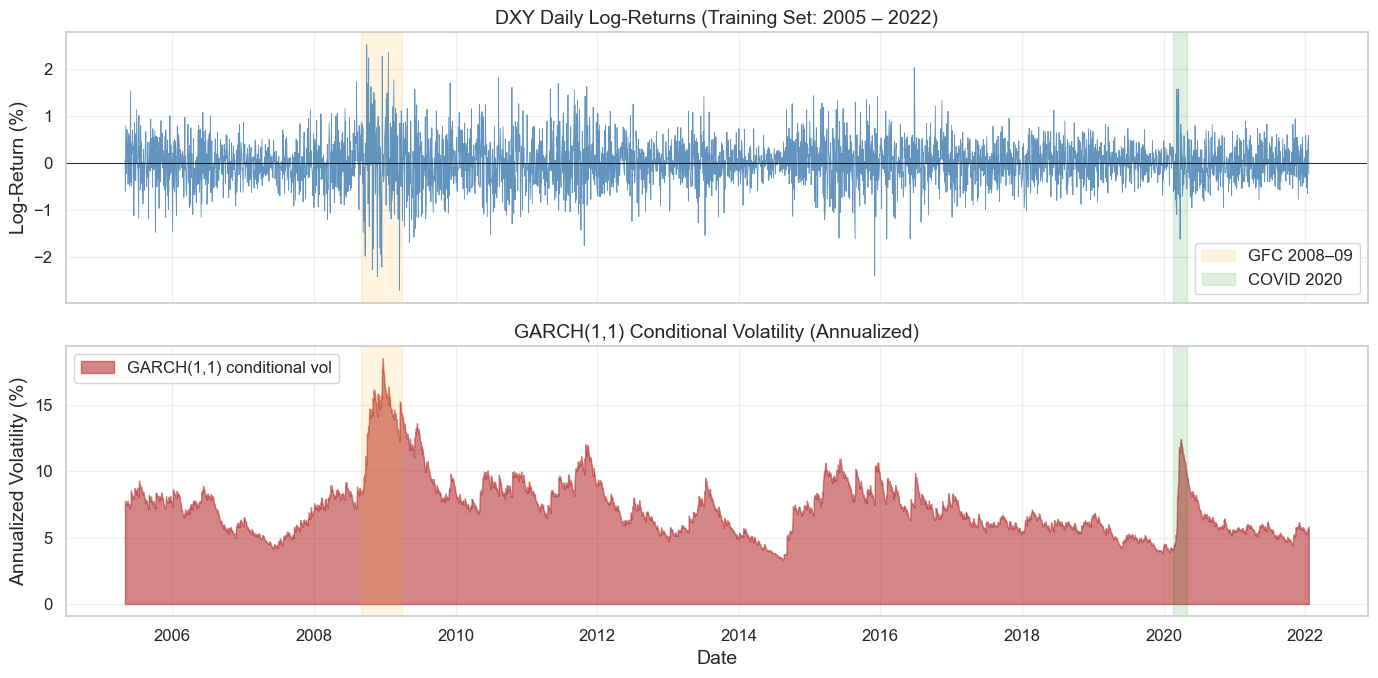

Fig 1 saved.


In [19]:
cond_vol_raw = arima_garch._garch_result.conditional_volatility  # scaled × 100
cond_vol     = cond_vol_raw / 100                                 # back to return scale
annual_vol   = cond_vol * np.sqrt(252)                            # annualized

# Align index — GARCH result aligns to training data
train_idx_aligned = y_train.index[-len(cond_vol):]

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# — Top: returns
axes[0].plot(y_train.index, y_train.values * 100,
             color='steelblue', lw=0.6, alpha=0.85)
axes[0].axhline(0, color='black', lw=0.6)
axes[0].set_ylabel('Log-Return (%)')
axes[0].set_title('DXY Daily Log-Returns (Training Set: 2005 – 2022)')

# — Bottom: conditional volatility
axes[1].fill_between(train_idx_aligned, annual_vol * 100,
                     alpha=0.55, color='firebrick', label='GARCH(1,1) conditional vol')
axes[1].set_ylabel('Annualized Volatility (%)')
axes[1].set_xlabel('Date')
axes[1].set_title('GARCH(1,1) Conditional Volatility (Annualized)')
axes[1].legend()

# Mark key events
for ax in axes:
    ax.axvspan(pd.Timestamp('2008-09-01'), pd.Timestamp('2009-03-31'),
               alpha=0.12, color='orange', label='GFC 2008–09')
    ax.axvspan(pd.Timestamp('2020-02-20'), pd.Timestamp('2020-04-30'),
               alpha=0.12, color='green',  label='COVID 2020')
axes[0].legend( loc='lower right')

plt.tight_layout()
plt.savefig('../reports/figures/fig1_garch_volatility.pdf', bbox_inches='tight')
plt.show()
print("Fig 1 saved.")





### Figure 2 — GARCH(1,1) Residual Diagnostics (4-panel)

**What it shows:** Four diagnostic panels for the standardized residuals from GARCH(1,1):
1. **Residuals over time** — should look like white noise with no volatility clustering
2. **Histogram vs Student-t** — validates the distributional assumption (heavy tails)
3. **QQ-plot vs Student-t** — confirms fit of the tail distribution
4. **ACF of squared residuals** — should be flat (no remaining ARCH effects)

**Thesis use:** This is the standard model validation chart for GARCH. If the squared
residuals show no autocorrelation (flat ACF), GARCH has fully captured the volatility
structure — confirming the model is correctly specified.


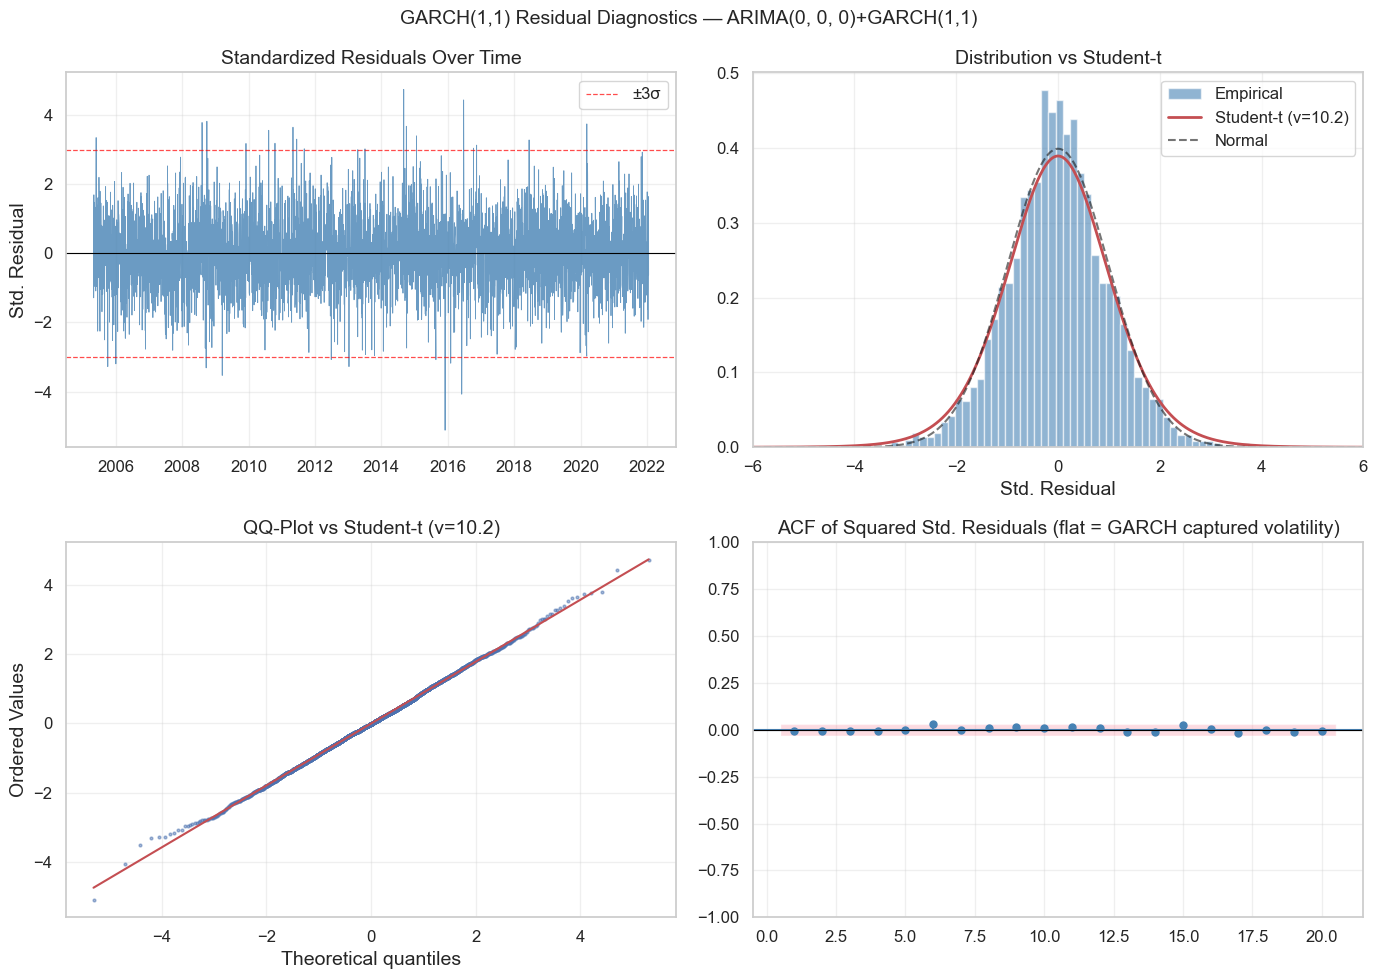

Fig 2 saved.


In [20]:
std_resid = arima_garch.std_resid.dropna()

# Fitted degrees of freedom from Student-t GARCH
try:
    nu = arima_garch._garch_result.params['nu']
except KeyError:
    nu = 5.0  # fallback

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# — Panel 1: residuals over time
axes[0, 0].plot(std_resid.index, std_resid.values,
                color='steelblue', lw=0.6, alpha=0.8)
axes[0, 0].axhline( 0, color='black',  lw=0.8)
axes[0, 0].axhline( 3, color='red',    lw=0.9, linestyle='--', alpha=0.7)
axes[0, 0].axhline(-3, color='red',    lw=0.9, linestyle='--', alpha=0.7, label='±3σ')
axes[0, 0].set_title('Standardized Residuals Over Time')
axes[0, 0].set_ylabel('Std. Residual')
axes[0, 0].legend()

# — Panel 2: histogram vs Student-t
x = np.linspace(-6, 6, 400)
axes[0, 1].hist(std_resid.values, bins=70, density=True,
                color='steelblue', alpha=0.6, label='Empirical')
axes[0, 1].plot(x, stats.t.pdf(x, df=nu), 'r-', lw=2,
                label=f'Student-t (ν={nu:.1f})')
axes[0, 1].plot(x, stats.norm.pdf(x), 'k--', lw=1.5,
                alpha=0.6, label='Normal')
axes[0, 1].set_title('Distribution vs Student-t')
axes[0, 1].set_xlabel('Std. Residual')
axes[0, 1].legend()
axes[0, 1].set_xlim(-6, 6)

# — Panel 3: QQ-plot vs Student-t
stats.probplot(std_resid.values, dist=stats.t, sparams=(nu), plot=axes[1, 0])
axes[1, 0].set_title(f'QQ-Plot vs Student-t (ν={nu:.1f})')
axes[1, 0].get_lines()[0].set(markersize=2, alpha=0.5)

# — Panel 4: ACF of squared residuals
plot_acf(std_resid.values ** 2, lags=20, ax=axes[1, 1], zero=False,
         color='steelblue', vlines_kwargs={'colors': 'steelblue'})
axes[1, 1].set_title('ACF of Squared Std. Residuals (flat = GARCH captured volatility)')
axes[1, 1].axhline(0, color='black', lw=0.8)

plt.suptitle(f'GARCH(1,1) Residual Diagnostics — ARIMA{arima_garch.order}+GARCH(1,1)')
plt.tight_layout()
plt.savefig('../reports/figures/fig2_garch_diagnostics.pdf', bbox_inches='tight')
plt.show()
print("Fig 2 saved.")





### Figure 3 — ACF and PACF: Raw Returns vs ARIMA Residuals

**What it shows:** Autocorrelation Function and Partial Autocorrelation Function
for (top) raw DXY returns and (bottom) ARIMA(p,d,q) residuals.

**Thesis use:** Demonstrates that the selected ARIMA order correctly captures the
autocorrelation structure in the mean equation. After filtering, the residuals
should show no significant spikes — confirming the ARIMA specification is adequate.
If spikes remain, the model is mis-specified.


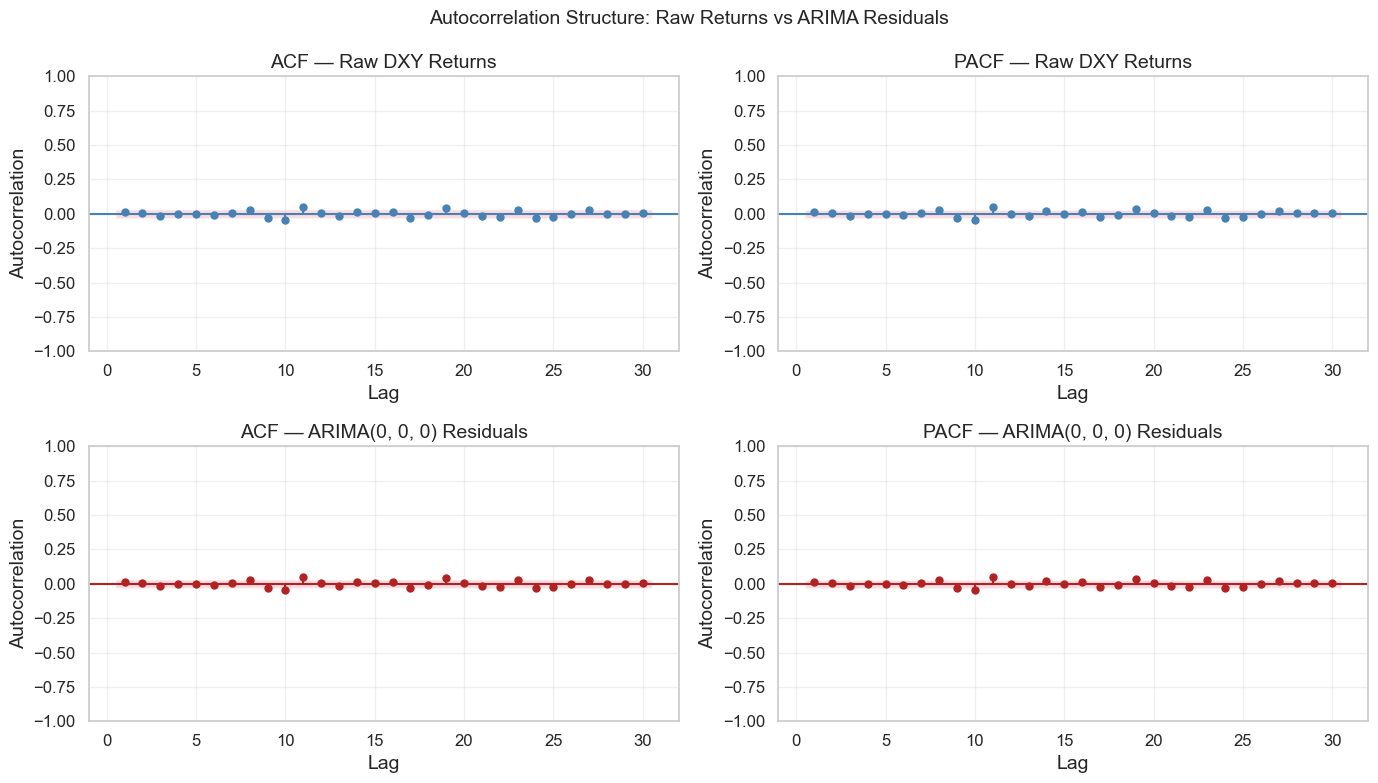

Fig 3 saved.


In [21]:
arima_resid = pd.Series(arima_garch._arima_result.resid).dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(y_train.dropna().values,  lags=30, ax=axes[0, 0], zero=False,
         color='steelblue', vlines_kwargs={'colors': 'steelblue'})
axes[0, 0].set_title('ACF — Raw DXY Returns')

plot_pacf(y_train.dropna().values, lags=30, ax=axes[0, 1], zero=False,
          method='ywm', color='steelblue', vlines_kwargs={'colors': 'steelblue'})
axes[0, 1].set_title('PACF — Raw DXY Returns')

plot_acf(arima_resid.values, lags=30, ax=axes[1, 0], zero=False,
         color='firebrick', vlines_kwargs={'colors': 'firebrick'})
axes[1, 0].set_title(f'ACF — ARIMA{arima_garch.order} Residuals')

plot_pacf(arima_resid.values, lags=30, ax=axes[1, 1], zero=False,
          method='ywm', color='firebrick', vlines_kwargs={'colors': 'firebrick'})
axes[1, 1].set_title(f'PACF — ARIMA{arima_garch.order} Residuals')

for ax in axes.flat:
    ax.set_xlabel('Lag')
    ax.set_ylabel('Autocorrelation')

plt.suptitle('Autocorrelation Structure: Raw Returns vs ARIMA Residuals')
plt.tight_layout()
plt.savefig('../reports/figures/fig3_acf_pacf.pdf', bbox_inches='tight')
plt.show()
print("Fig 3 saved.")




### Figure 4 — Rolling OOS Forecasts vs Actual DXY Returns

**What it shows:** One-step-ahead out-of-sample predictions from all five models
plotted against realized DXY log-returns over the test period (2022 – 2026).

**Thesis use:** Visual evidence that all models track each other closely and
stay near the baseline ARIMA(0,0,0). No model systematically deviates from
the random walk — consistent with the DM test result. Also shows how all
forecasts collapse toward zero (the unconditional mean) — the hallmark
of an efficient market where returns are not predictable.


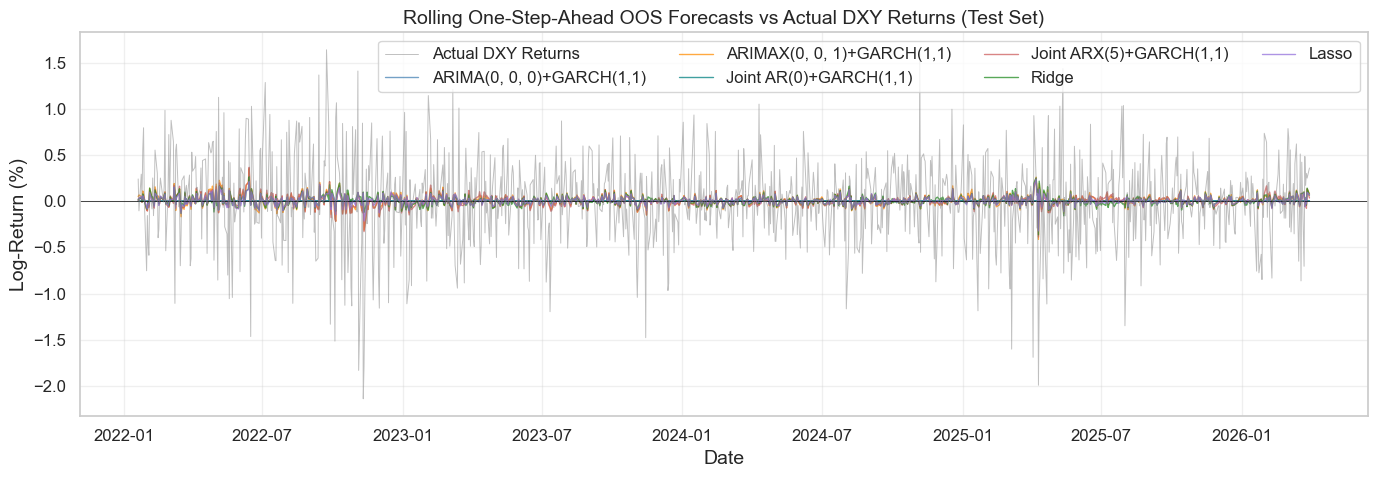

Fig 4 saved.


In [22]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(actual_s.index, actual_s.values * 100,
        color='gray', lw=0.7, alpha=0.5, label='Actual DXY Returns', zorder=5)
ax.plot(actual_s.index, ag_pred   * 100, color='steelblue',  lw=1.0,
        alpha=0.75, label=ag_label)
ax.plot(actual_s.index, axg_pred  * 100, color='darkorange', lw=1.0,
        alpha=0.75, label=axg_label)
ax.plot(actual_s.index, jar_pred  * 100, color='teal', lw=1.0,
        alpha=0.75, label=jar_label)
ax.plot(actual_s.index, jarx_pred * 100, color='indianred', lw=1.0,
        alpha=0.75, label=jarx_label)
ax.plot(actual_s.index, ridge_pred * 100, color='forestgreen', lw=1.0,
        alpha=0.75, label='Ridge')
ax.plot(actual_s.index, lasso_pred * 100, color='mediumpurple', lw=1.0,
        alpha=0.75, label='Lasso')

ax.axhline(0, color='black', lw=0.5)
ax.set_title('Rolling One-Step-Ahead OOS Forecasts vs Actual DXY Returns (Test Set)')
ax.set_xlabel('Date')
ax.set_ylabel('Log-Return (%)')
ax.legend(loc='upper right', ncol=4)
plt.tight_layout()
plt.savefig('../reports/figures/fig4_rolling_forecasts.pdf', bbox_inches='tight')
plt.show()
print("Fig 4 saved.")




### Figure 5 — Out-of-Sample RMSE Comparison

**What it shows:** Horizontal bar chart of RMSE for all five models on the test set.
The dashed line marks the ARIMA(0,0,0) baseline (random walk) RMSE.

**Thesis use:** Clean visual summary of the model comparison table. Shows whether
any model achieves a meaningful RMSE reduction over the random walk. Even a small
difference is informative — if models with 9 cross-asset features barely improve over
a constant-mean baseline, this strongly supports EMH.


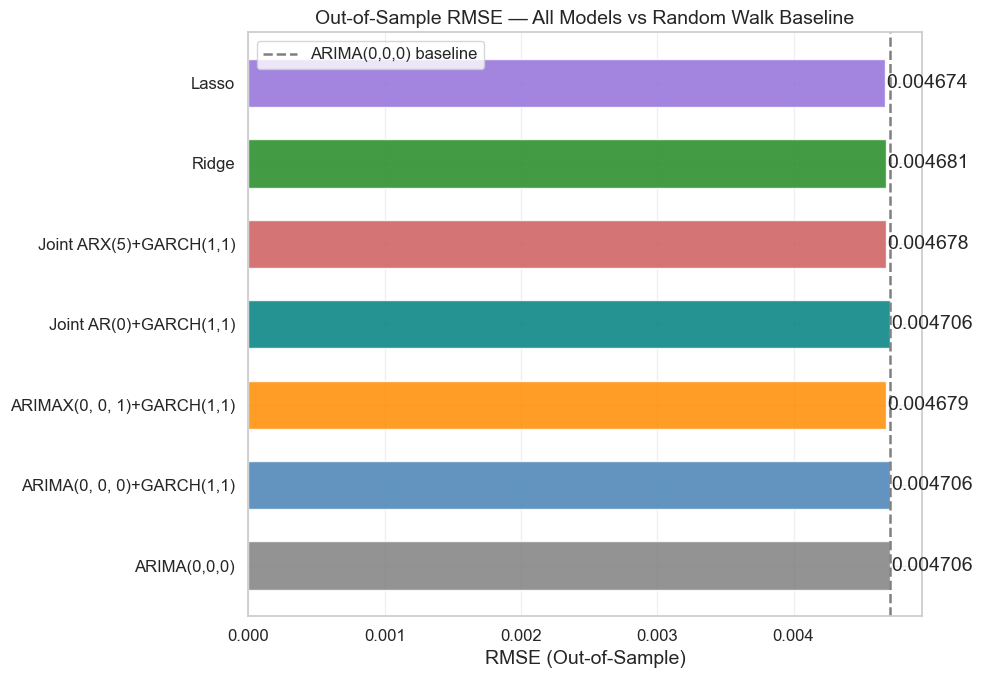

Fig 5 saved.


In [23]:
model_colors = {
    'ARIMA(0,0,0)': 'gray',
    ag_label:       'steelblue',
    axg_label:      'darkorange',
    jar_label:      'teal',
    jarx_label:     'indianred',
    'Ridge':        'forestgreen',
    'Lasso':        'mediumpurple',
}

rmse_dict = {}
for name, pred in [('ARIMA(0,0,0)', bl_pred), (ag_label, ag_pred),
                   (axg_label, axg_pred), (jar_label, jar_pred),
                   (jarx_label, jarx_pred), ('Ridge', ridge_pred), ('Lasso', lasso_pred)]:
    rmse_dict[name] = np.sqrt(np.mean((actual_s.values - pred) ** 2))

names_sorted = list(rmse_dict.keys())
rmse_vals    = [rmse_dict[n] for n in names_sorted]
colors_bar   = [model_colors.get(n, 'steelblue') for n in names_sorted]
baseline_rmse = rmse_dict['ARIMA(0,0,0)']

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(range(len(names_sorted)), rmse_vals,
               color=colors_bar, alpha=0.85, edgecolor='white', height=0.6)
ax.set_yticks(range(len(names_sorted)))
ax.set_yticklabels(names_sorted)
ax.set_xlabel('RMSE (Out-of-Sample)')
ax.set_title('Out-of-Sample RMSE — All Models vs Random Walk Baseline')
ax.axvline(baseline_rmse, color='gray', linestyle='--', lw=1.8, label='ARIMA(0,0,0) baseline')

for i, v in enumerate(rmse_vals):
    ax.text(v + baseline_rmse * 0.002, i, f'{v:.6f}', va='center')

ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/fig5_rmse_comparison.pdf', bbox_inches='tight')
plt.show()
print("Fig 5 saved.")





### Figure 6 — Rolling 63-Day RMSE Over Time

**What it shows:** RMSE computed over a rolling 63-trading-day window (~3 months)
for each model across the test period.

**Thesis use:** Reveals whether any model is better during specific market regimes
(e.g. crisis periods, high-volatility regimes). If all models converge during crises
and diverge in calm periods — or vice versa — this is informative for the thesis
conclusion about when ARIMA/ARIMAX structure matters most.


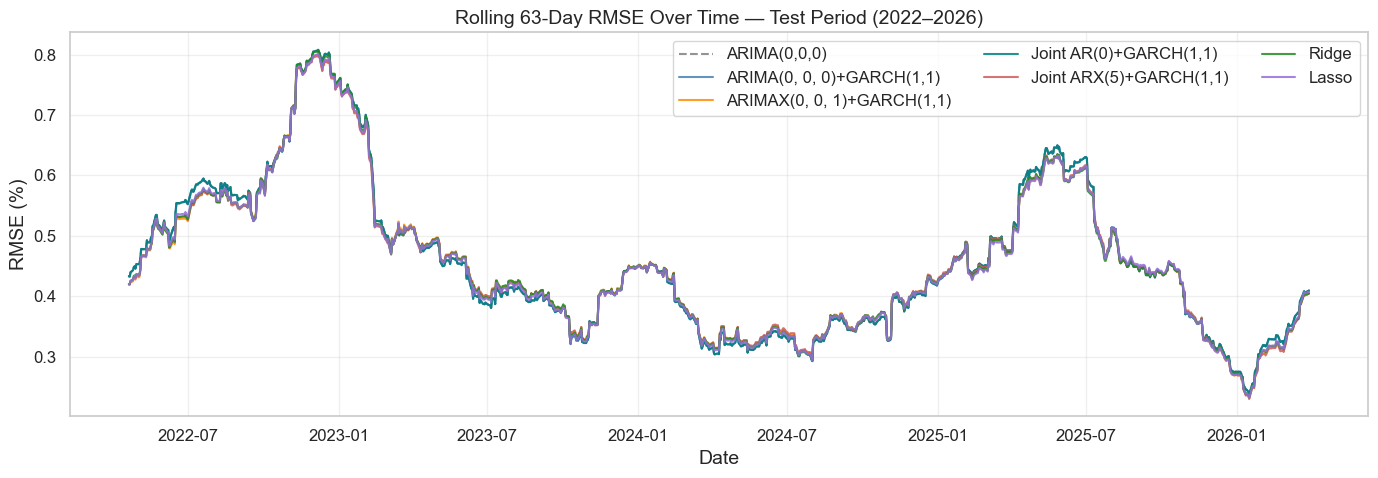

Fig 6 saved.


In [24]:
window = 63  # 3-month rolling window

fig, ax = plt.subplots(figsize=(14, 5))

model_preds = [
    ('ARIMA(0,0,0)', bl_pred,    'gray',         '--'),
    (ag_label,        ag_pred,   'steelblue',    '-'),
    (axg_label,       axg_pred,  'darkorange',   '-'),
(jar_label,       jar_pred,  'teal',         '-'),
(jarx_label,      jarx_pred, 'indianred',    '-'),
    ('Ridge',         ridge_pred,'forestgreen',  '-'),
    ('Lasso',         lasso_pred,'mediumpurple', '-'),
]

for name, pred_arr, color, ls in model_preds:
    sq_err = (actual_s.values - pred_arr) ** 2
    roll_rmse = pd.Series(sq_err, index=actual_s.index).rolling(window).mean() ** 0.5
    ax.plot(roll_rmse.index, roll_rmse.values * 100,
            label=name, color=color, lw=1.5, linestyle=ls, alpha=0.85)

ax.set_title(f'Rolling {window}-Day RMSE Over Time — Test Period (2022–2026)')
ax.set_ylabel('RMSE (%)')
ax.set_xlabel('Date')
ax.legend( ncol=3)
plt.tight_layout()
plt.savefig('../reports/figures/fig6_rolling_rmse.pdf', bbox_inches='tight')
plt.show()
print("Fig 6 saved.")




### Figure 7 — Ridge and Lasso Coefficient Comparison

**What it shows:** Coefficient values for all 15 features in Ridge (L2) and Lasso (L1)
regression models trained on the full training set.

**Thesis use:** Shows which cross-asset factors the linear models consider most
informative for predicting DXY returns. Lasso performs feature selection (some
coefficients exactly zero) while Ridge shrinks all coefficients toward zero.
The comparison highlights which features are robust across both regularization
approaches — a feature selected by both is more credible.


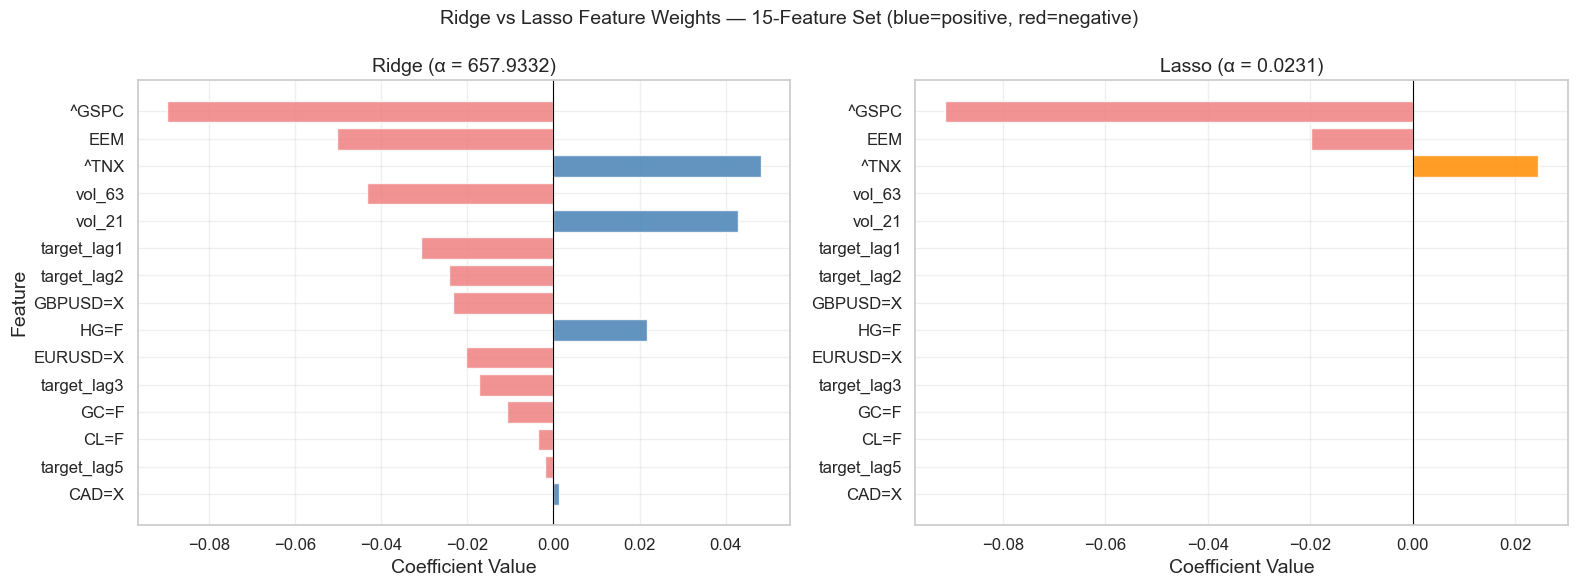

Fig 7 saved.

✓ All 7 figures saved to ../reports/figures/


In [25]:
ridge_coef = pd.Series(ridge.model.coef_,  index=ridge.feature_names)
lasso_coef = pd.Series(lasso.model.coef_,  index=lasso.feature_names)

# Align to common feature order (sorted by |Ridge| importance)
feature_order = ridge_coef.abs().sort_values(ascending=True).index

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, coef, name, color in [
    (axes[0], ridge_coef.loc[feature_order], 'Ridge', 'steelblue'),
    (axes[1], lasso_coef.loc[feature_order], 'Lasso', 'darkorange'),
]:
    bar_colors = [color if v > 0 else 'lightcoral' for v in coef.values]
    ax.barh(coef.index, coef.values,
            color=bar_colors, alpha=0.85, edgecolor='white')
    ax.axvline(0, color='black', lw=0.8)
    alpha_val = ridge.alpha if name == 'Ridge' else lasso.alpha
    ax.set_title(f'{name} (α = {alpha_val:.4f})')
    ax.set_xlabel('Coefficient Value')

axes[0].set_ylabel('Feature')
plt.suptitle('Ridge vs Lasso Feature Weights — 15-Feature Set (blue=positive, red=negative)')
plt.tight_layout()
plt.savefig('../reports/figures/fig7_ridge_lasso_coefs.pdf', bbox_inches='tight')
plt.show()
print("Fig 7 saved.")
print(f"\n✓ All 7 figures saved to ../reports/figures/")




## Appendix — illustration: joint `arch` AR(1)+GARCH vs AIC-selected joint AR

On DXY, `auto_arima` often selects **(0,0,0)** for the two-step mean; the **joint `arch`** benchmark may also pick **p = 0**. This appendix fits **one** extra specification by **joint MLE** — **AR(1)+GARCH(1,1)** (`ARIMAGARCHModel`, `best_lags=1`, `select_lags=False`), runs the **same** rolling one-step OOS as `joint_ar`, and compares to the **already fitted** `joint_ar` using the **same two tests** as in §5: **Diebold–Mariano** (squared loss; H₀ equal accuracy) and **two-sided binomial** (p = 0.5 vs ≠ 0.5 for correct sign) as in §5. Use the printed **table** in the thesis if a contrast row is needed.

**Why RMSE can look “the same” for p = 0 vs p > 0:** one-step OOS RMSE is dominated by the **unpredictable variance of returns** \((r_t - \hat r_t)^2 \approx \varepsilon_t^2\) when the conditional mean \(\hat r_t\) is small (near zero) and AR terms are **weak** after joint MLE. Mean forecasts then differ only in the **4th–6th decimal**; rounding to **4 decimals** (or the default `DataFrame` display) makes RMSE look identical even though predictions are not. The cell below prints **high-precision RMSE** and **max / mean absolute forecast difference** so the gap is visible.

In [26]:
from scipy.stats import binomtest

joint_ar1_ill = ARIMAGARCHModel(max_lags=5, information_criterion="aic")
joint_ar1_ill.best_lags = 1
joint_ar1_ill.fit(y_train, select_lags=False)
joint_ar1_label = "Joint AR(1)+GARCH(1,1) [forced illustration, arch MLE]"
joint_ar1_results = joint_ar1_ill.rolling_forecast(
    y, train_size=train_size, horizon=1, refit_every=21
)

_ix_j = joint_ar_results.index.intersection(joint_ar1_results.index)
_act_j = joint_ar_results.loc[_ix_j, "actual"].values
_pred_sel = joint_ar_results.loc[_ix_j, "predicted"].values
_pred_1 = joint_ar1_results.loc[_ix_j, "predicted"].values
_nj = len(_act_j)

_rmse_sel = metrics_calc.rmse(_act_j, _pred_sel)
_rmse_1 = metrics_calc.rmse(_act_j, _pred_1)
_dm_j, _dm_p_j = metrics_calc.diebold_mariano_test(
    _act_j, _pred_1, _pred_sel, loss="squared"
)
_corr_sel = (np.sign(_act_j) == np.sign(_pred_sel)).sum()
_corr_1 = (np.sign(_act_j) == np.sign(_pred_1)).sum()
_bt_sel = binomtest(_corr_sel, _nj, p=0.5, alternative="two-sided")
_bt_1 = binomtest(_corr_1, _nj, p=0.5, alternative="two-sided")

print("=" * 72)
print("  APPENDIX — Joint arch: selected vs forced AR(1)")
print("=" * 72)
print(f"  Selected: {jar_label}  |  Illustration: {joint_ar1_label}")
print(f"  Aligned OOS rows: {_nj}")
_dpred = np.abs(_pred_sel - _pred_1)
print(f"\n  RMSE (vs actual) — also shown with extra digits (mean forecasts are tiny)")
print(f"    {jar_label}:  {_rmse_sel:.6f}  (full: {_rmse_sel:.10f})")
print(f"    {joint_ar1_label}:  {_rmse_1:.6f}  (full: {_rmse_1:.10f})")
print(f"    |RMSE forced − RMSE selected| = {abs(_rmse_1 - _rmse_sel):.2e}")
print(f"    max |pred_forced − pred_selected| = {_dpred.max():.2e}  mean = {_dpred.mean():.2e}")
print(f"\n  Diebold–Mariano (squared loss) — forced AR(1) vs selected")
print(f"    DM statistic = {_dm_j:.4f}   p-value = {_dm_p_j:.4f}")
print("    (Negative DM → forced model better; positive → selected better)")
print(f"\n  Binomial test — H0: p=0.5 (two-sided, alternative='two-sided')")
print(f"    {jar_label}:  {_corr_sel}/{_nj} ({100*_corr_sel/_nj:.2f}%)  p = {_bt_sel.pvalue:.4f}")
print(f"    {joint_ar1_label}:  {_corr_1}/{_nj} ({100*_corr_1/_nj:.2f}%)  p = {_bt_1.pvalue:.4f}")

_tbl_j = pd.DataFrame(
    {
        "Model": [jar_label, joint_ar1_label],
        "RMSE": [_rmse_sel, _rmse_1],
        "DM vs selected": [0.0, _dm_j],
        "DM p-value": [np.nan, _dm_p_j],
        "Directional %": [100 * _corr_sel / _nj, 100 * _corr_1 / _nj],
        "Binomial p-value": [_bt_sel.pvalue, _bt_1.pvalue],
    }
)
print("\n  Table (copy for thesis):")
print(_tbl_j.to_string(index=False, float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else f"{x}"))
print("=" * 72)


  APPENDIX — Joint arch: selected vs forced AR(1)
  Selected: Joint AR(0)+GARCH(1,1)  |  Illustration: Joint AR(1)+GARCH(1,1) [forced illustration, arch MLE]
  Aligned OOS rows: 1053

  RMSE (vs actual) — also shown with extra digits (mean forecasts are tiny)
    Joint AR(0)+GARCH(1,1):  0.004706  (full: 0.0047058446)
    Joint AR(1)+GARCH(1,1) [forced illustration, arch MLE]:  0.004706  (full: 0.0047055883)
    |RMSE forced − RMSE selected| = 2.56e-07
    max |pred_forced − pred_selected| = 2.36e-05  mean = 4.33e-06

  Diebold–Mariano (squared loss) — forced AR(1) vs selected
    DM statistic = -1.0653   p-value = 0.2870
    (Negative DM → forced model better; positive → selected better)

  Binomial test — H0: p=0.5 (two-sided, alternative='two-sided')
    Joint AR(0)+GARCH(1,1):  543/1053 (51.57%)  p = 0.3241
    Joint AR(1)+GARCH(1,1) [forced illustration, arch MLE]:  543/1053 (51.57%)  p = 0.3241

  Table (copy for thesis):
                                                 Model   R